# PYPL-like анализ языков программирования через Yandex Wordstat

В этом ноутбуке анализируются все языки, импортированные из таблицы проекта PYPL. Все расчеты выполняются по полному набору языков, а графики строятся только для 10 наиболее перспективных языков, чтобы визуализация оставалась читаемой.

## 1. Импорт библиотек

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## 2. Пути к данным

In [2]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"

RAW_DATA_PATH = DATA_DIR / "wordstat_dynamics_raw.csv"
MONTHLY_INDEX_PATH = DATA_DIR / "wordstat_monthly_index.csv"
LATEST_RANKING_PATH = DATA_DIR / "wordstat_latest_ranking.csv"
TOP10_RANKING_PATH = DATA_DIR / "wordstat_top10_promising_languages.csv"
PYPL_REFERENCE_PATH = DATA_DIR / "pypl_reference.csv"

RAW_DATA_PATH, MONTHLY_INDEX_PATH, LATEST_RANKING_PATH, TOP10_RANKING_PATH, PYPL_REFERENCE_PATH

(PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/wordstat_dynamics_raw.csv'),
 PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/wordstat_monthly_index.csv'),
 PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/wordstat_latest_ranking.csv'),
 PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/wordstat_top10_promising_languages.csv'),
 PosixPath('/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/data/pypl_reference.csv'))

## 3. Загрузка таблиц

Загружаем данные Yandex Wordstat, результаты расчета индекса и таблицу проекта PYPL.

In [3]:
raw_df = pd.read_csv(RAW_DATA_PATH)
raw_df["date"] = pd.to_datetime(raw_df["date"], utc=True).dt.tz_localize(None)

monthly_index_df = pd.read_csv(MONTHLY_INDEX_PATH)
monthly_index_df["date"] = pd.to_datetime(monthly_index_df["date"], utc=True).dt.tz_localize(None)

latest_ranking_df = pd.read_csv(LATEST_RANKING_PATH)
latest_ranking_df["date"] = pd.to_datetime(latest_ranking_df["date"], utc=True).dt.tz_localize(None)

top10_ranking_df = pd.read_csv(TOP10_RANKING_PATH)
top10_ranking_df["date"] = pd.to_datetime(top10_ranking_df["date"], utc=True).dt.tz_localize(None)

pypl_df = pd.read_csv(PYPL_REFERENCE_PATH)
pypl_df["date"] = pd.to_datetime(pypl_df["date"])

print('Raw rows:', len(raw_df))
print('Monthly index rows:', len(monthly_index_df))
print('Languages in Wordstat:', monthly_index_df['language'].nunique())
print('Languages in PYPL table:', len(pypl_df.columns) - 1)

Raw rows: 3000
Monthly index rows: 3000
Languages in Wordstat: 30
Languages in PYPL table: 30


## 4. Полный набор языков исследования

Исследование использует все языки, которые были спарсены из таблицы проекта PYPL.

In [4]:
all_languages = sorted(monthly_index_df['language'].unique().tolist())
all_languages

['Abap',
 'Ada',
 'C#',
 'C/C++',
 'Cobol',
 'Dart',
 'Delphi/Pascal',
 'Go',
 'Groovy',
 'Haskell',
 'Java',
 'JavaScript',
 'Julia',
 'Kotlin',
 'Lua',
 'Matlab',
 'Objective-C',
 'PHP',
 'Perl',
 'Powershell',
 'Python',
 'R',
 'Ruby',
 'Rust',
 'Scala',
 'Swift',
 'TypeScript',
 'VBA',
 'Visual Basic',
 'Zig']

## 5. Топ-10 наиболее перспективных языков

Перспективность определяется по годовому тренду `yearly_trend_pp`. На графиках будет показан только этот набор.

In [5]:
top10_ranking_df[['language', 'share_pct', 'average_share_pct', 'yearly_trend_pp']]

,language,share_pct,average_share_pct,yearly_trend_pp
0,C/C++,27.5145,23.0085,8.3691
1,PHP,8.2081,8.2260,1.4555
2,Rust,4.5087,2.8890,0.6877
3,Ruby,3.5260,1.6398,0.2460
4,Haskell,0.0000,0.3742,0.1945
5,Matlab,0.0000,1.1549,0.0692
6,R,0.0000,0.0217,0.0000
7,Abap,0.0000,0.1201,0.0000
8,Perl,0.0000,0.1789,0.0000
9,Objective-C,0.0000,0.0390,0.0000


In [6]:
top10_languages = top10_ranking_df['language'].tolist()
top5_first = top10_languages[:5]
top5_second = top10_languages[5:10]

print('Top 1-5:', top5_first)
print('Top 6-10:', top5_second)

Top 1-5: ['C/C++', 'PHP', 'Rust', 'Ruby', 'Haskell']
Top 6-10: ['Matlab', 'R', 'Abap', 'Perl', 'Objective-C']


## 6. Графики Wordstat для top-10 языков

Чтобы графики не сливались, на каждом отображается не больше пяти языков.

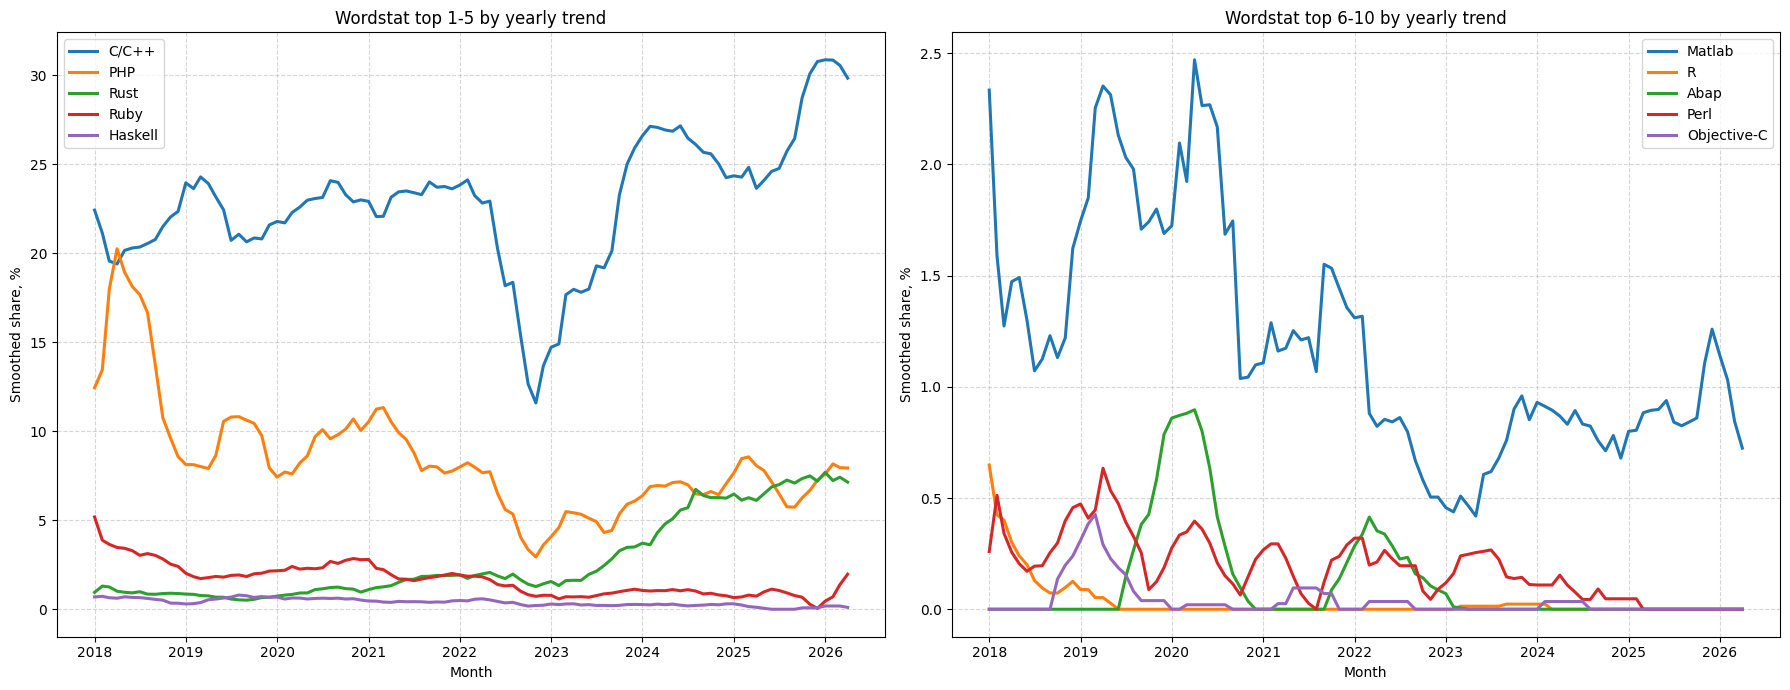

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharex=True)

for language in top5_first:
    language_df = monthly_index_df[monthly_index_df['language'] == language]
    axes[0].plot(language_df['date'], language_df['smoothed_share_pct'], linewidth=2.2, label=language)

for language in top5_second:
    language_df = monthly_index_df[monthly_index_df['language'] == language]
    axes[1].plot(language_df['date'], language_df['smoothed_share_pct'], linewidth=2.2, label=language)

axes[0].set_title('Wordstat top 1-5 by yearly trend')
axes[1].set_title('Wordstat top 6-10 by yearly trend')

for ax in axes:
    ax.set_xlabel('Month')
    ax.set_ylabel('Smoothed share, %')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Бар-чарты top-10

Показываем top-10 по текущей доле и по годовому тренду.

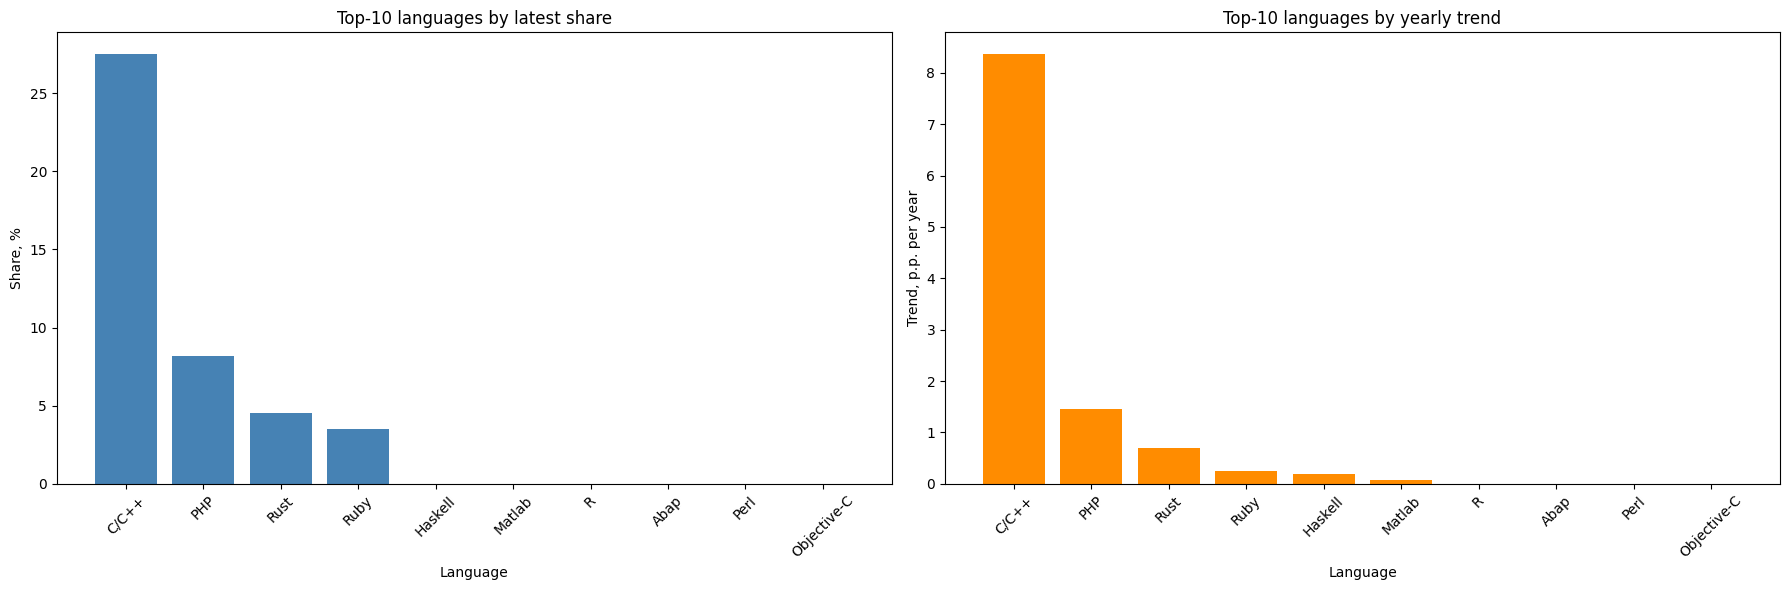

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

share_df = top10_ranking_df.sort_values('share_pct', ascending=False)
trend_df = top10_ranking_df.sort_values('yearly_trend_pp', ascending=False)

axes[0].bar(share_df['language'], share_df['share_pct'], color='steelblue')
axes[0].set_title('Top-10 languages by latest share')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Share, %')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(trend_df['language'], trend_df['yearly_trend_pp'], color='darkorange')
axes[1].set_title('Top-10 languages by yearly trend')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Trend, p.p. per year')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 8. Подготовка данных к сравнению с проектом PYPL

Сравнение выполняется по всем языкам, которые одновременно присутствуют и в данных Wordstat, и в таблице проекта PYPL.

In [9]:
wordstat_wide_df = monthly_index_df.pivot(index='date', columns='language', values='smoothed_share_pct').reset_index()
common_languages = [language for language in pypl_df.columns if language != 'date' and language in wordstat_wide_df.columns]
comparison_df = wordstat_wide_df[['date', *common_languages]].merge(pypl_df[['date', *common_languages]], on='date', suffixes=('_wordstat', '_pypl'))
comparison_df = comparison_df.sort_values('date').reset_index(drop=True)

print('Common languages:', len(common_languages))
print(common_languages)
print('Months compared:', len(comparison_df))

Common languages: 30
['Abap', 'Ada', 'C/C++', 'C#', 'Cobol', 'Dart', 'Delphi/Pascal', 'Go', 'Groovy', 'Haskell', 'Java', 'JavaScript', 'Julia', 'Kotlin', 'Lua', 'Matlab', 'Objective-C', 'Perl', 'PHP', 'Powershell', 'Python', 'R', 'Ruby', 'Rust', 'Scala', 'Swift', 'TypeScript', 'VBA', 'Visual Basic', 'Zig']
Months compared: 100


## 9. Графики рядом: Wordstat vs проект PYPL для top-10

Для наглядности сравниваем только top-10 наиболее перспективных языков, но все численные метрики далее считаются по полному пересечению языков.

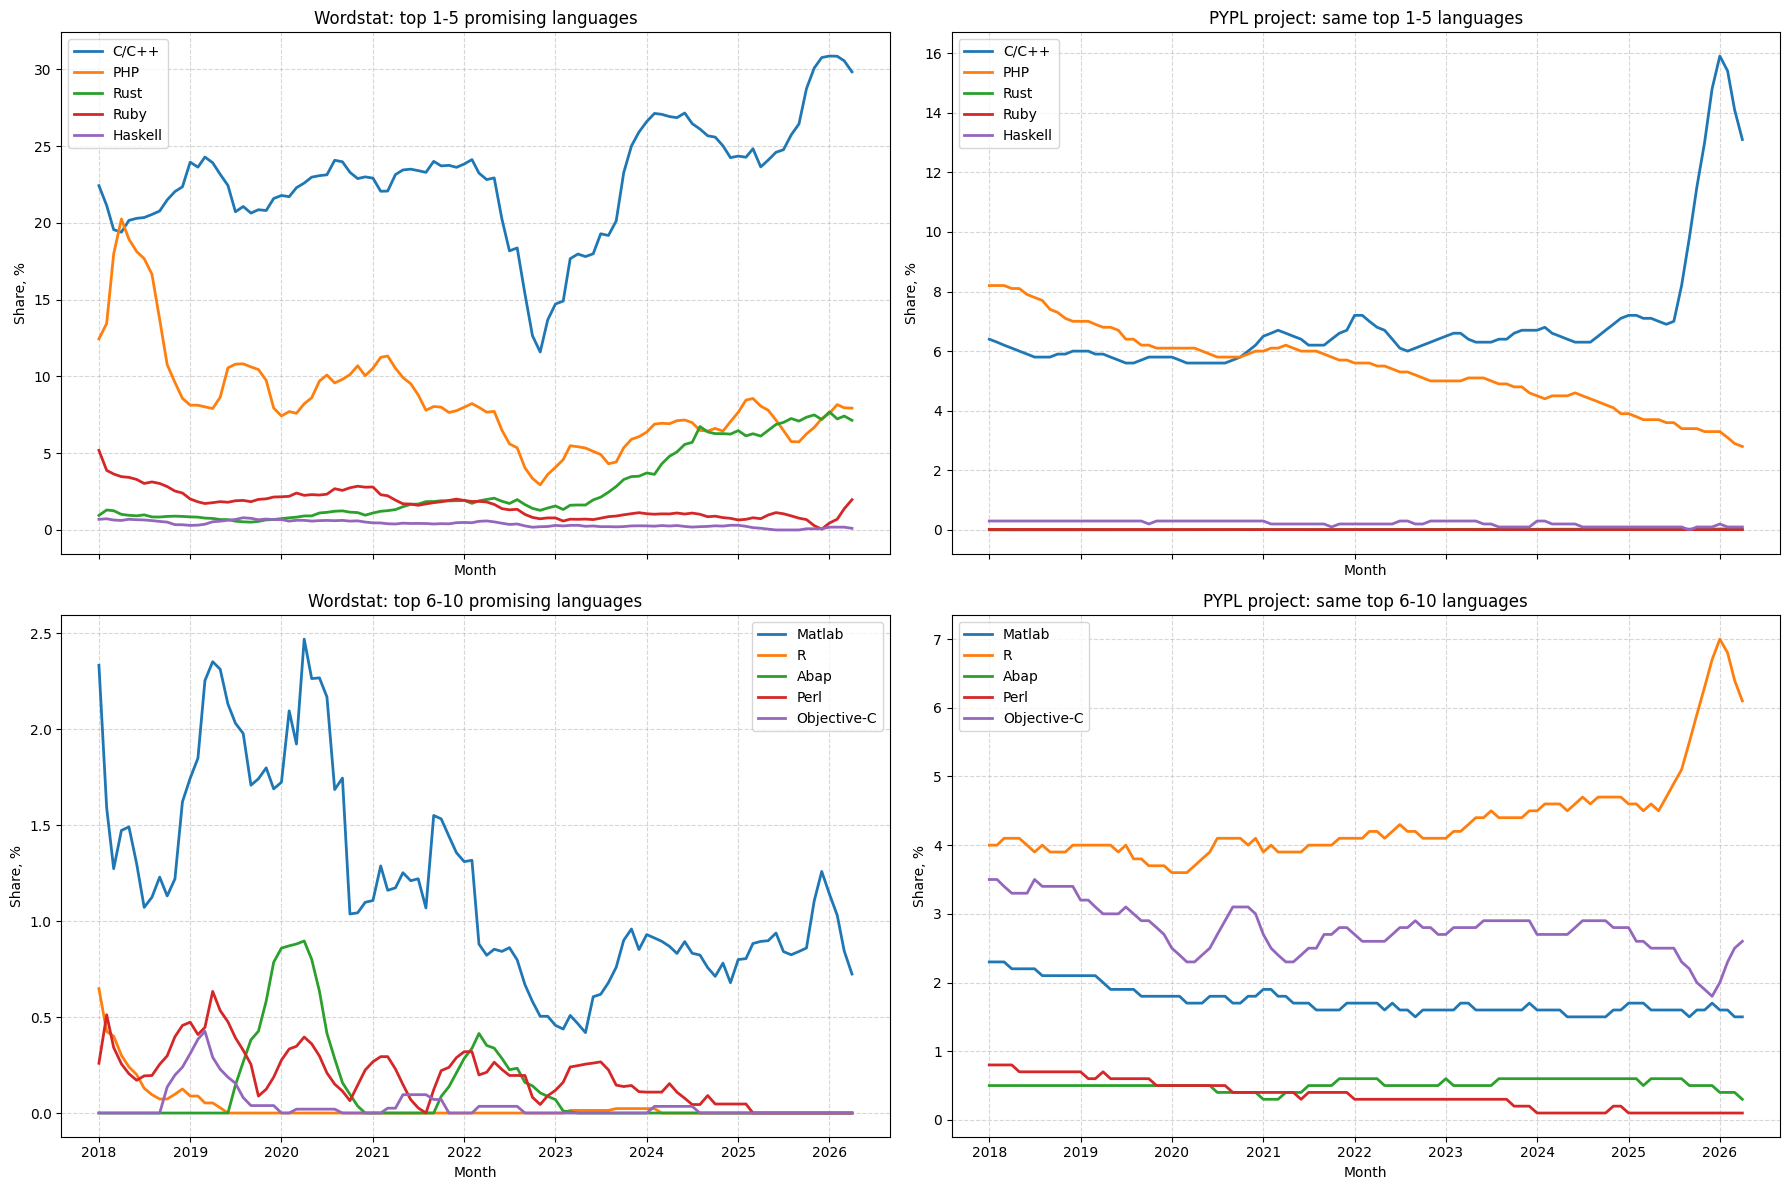

In [10]:
comparison_top10 = [language for language in top10_languages if language in common_languages]
comparison_top5_first = comparison_top10[:5]
comparison_top5_second = comparison_top10[5:10]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)

for language in comparison_top5_first:
    axes[0, 0].plot(comparison_df['date'], comparison_df[f'{language}_wordstat'], linewidth=2.0, label=language)
    axes[0, 1].plot(comparison_df['date'], comparison_df[f'{language}_pypl'], linewidth=2.0, label=language)

for language in comparison_top5_second:
    axes[1, 0].plot(comparison_df['date'], comparison_df[f'{language}_wordstat'], linewidth=2.0, label=language)
    axes[1, 1].plot(comparison_df['date'], comparison_df[f'{language}_pypl'], linewidth=2.0, label=language)

axes[0, 0].set_title('Wordstat: top 1-5 promising languages')
axes[0, 1].set_title('PYPL project: same top 1-5 languages')
axes[1, 0].set_title('Wordstat: top 6-10 promising languages')
axes[1, 1].set_title('PYPL project: same top 6-10 languages')

for row in axes:
    for ax in row:
        ax.set_xlabel('Month')
        ax.set_ylabel('Share, %')
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()

plt.tight_layout()
plt.show()

## 10. Численное сравнение по всем языкам

Считаем метрики сходства для всего пересечения языков, а не только для top-10.

In [11]:
rows = []

for language in common_languages:
    wordstat_series = comparison_df[f'{language}_wordstat']
    pypl_series = comparison_df[f'{language}_pypl']
    rows.append(
        {
            'language': language,
            'pearson_corr': round(wordstat_series.corr(pypl_series, method='pearson'), 4),
            'spearman_corr': round(wordstat_series.corr(pypl_series, method='spearman'), 4),
            'mae_share_pct': round((wordstat_series - pypl_series).abs().mean(), 4),
            'latest_gap_pct_points': round(wordstat_series.iloc[-1] - pypl_series.iloc[-1], 4),
        }
    )

metrics_df = pd.DataFrame(rows).sort_values('pearson_corr', ascending=False).reset_index(drop=True)
metrics_df.head(15)

/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/damirhanov/PycharmProjects/github-language-trends-analyzer/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,language,pearson_corr,spearman_corr,mae_share_pct,latest_gap_pct_points
0,Rust,0.9051,0.9170,2.7386,7.1123
1,Scala,0.8987,0.8795,0.4924,-0.0030
2,Visual Basic,0.8497,0.8058,0.2796,-0.0020
3,Ruby,0.8123,0.7392,1.6592,1.9602
4,Java,0.8121,0.8104,2.3701,1.7229
5,Perl,0.7413,0.7527,0.1772,-0.1000
6,Dart,0.7122,0.8208,0.2759,-0.5406
7,Haskell,0.7025,0.6889,0.1864,0.0046
8,VBA,0.6966,0.7479,0.5018,0.0980
9,Kotlin,0.6928,0.5687,0.8316,1.3060


## 11. Ранговое сравнение по всем языкам

In [12]:
rank_rows = []
leader_matches = 0

for _, row in comparison_df.iterrows():
    wordstat_values = {language: row[f'{language}_wordstat'] for language in common_languages}
    pypl_values = {language: row[f'{language}_pypl'] for language in common_languages}
    wordstat_rank = pd.Series(wordstat_values).rank(ascending=False, method='average')
    pypl_rank = pd.Series(pypl_values).rank(ascending=False, method='average')
    rank_corr = wordstat_rank.corr(pypl_rank, method='spearman')

    wordstat_leader = max(wordstat_values, key=wordstat_values.get)
    pypl_leader = max(pypl_values, key=pypl_values.get)
    leader_match = wordstat_leader == pypl_leader
    if leader_match:
        leader_matches += 1

    rank_rows.append(
        {
            'date': row['date'],
            'rank_corr': rank_corr,
            'wordstat_leader': wordstat_leader,
            'pypl_leader': pypl_leader,
            'leader_match': leader_match,
        }
    )

rank_comparison_df = pd.DataFrame(rank_rows)
pd.DataFrame({
    'metric': ['Average monthly rank correlation', 'Median monthly rank correlation', 'Leader match ratio'],
    'value': [round(rank_comparison_df['rank_corr'].mean(), 4), round(rank_comparison_df['rank_corr'].median(), 4), round(leader_matches / len(rank_comparison_df), 4)]
})

,metric,value
0,Average monthly rank correlation,0.3130
1,Median monthly rank correlation,0.3088
2,Leader match ratio,0.7700


## 12. Итоговые выводы

In [13]:
best_match_row = metrics_df.iloc[0]
worst_match_row = metrics_df.iloc[-1]
average_rank_corr = rank_comparison_df['rank_corr'].mean()
leader_match_ratio = leader_matches / len(rank_comparison_df)

print('Краткие выводы:')
print(f'- В полном исследовании использовано языков: {len(all_languages)}')
print(f'- Для сравнения с проектом PYPL использовано общих языков: {len(common_languages)}')
print(f'- На графиках показаны 10 наиболее перспективных языков по годовому тренду.')
print(f'- Наиболее близкий к данным проекта PYPL по форме ряда язык: {best_match_row["language"]} (Pearson = {best_match_row["pearson_corr"]}, Spearman = {best_match_row["spearman_corr"]}).')
print(f'- Наименее похожий язык: {worst_match_row["language"]} (Pearson = {worst_match_row["pearson_corr"]}, Spearman = {worst_match_row["spearman_corr"]}).')
print(f'- Средняя ранговая корреляция по месяцам: {average_rank_corr:.4f}')
print(f'- Доля месяцев, в которых совпал язык-лидер: {leader_match_ratio:.2%}')
print('- Итог: расчеты выполнялись по полному набору языков, а визуализация была ограничена top-10 для читаемости графиков.')

Краткие выводы:
- В полном исследовании использовано языков: 30
- Для сравнения с проектом PYPL использовано общих языков: 30
- На графиках показаны 10 наиболее перспективных языков по годовому тренду.
- Наиболее близкий к данным проекта PYPL по форме ряда язык: Rust (Pearson = 0.9051, Spearman = 0.917).
- Наименее похожий язык: C# (Pearson = nan, Spearman = nan).
- Средняя ранговая корреляция по месяцам: 0.3130
- Доля месяцев, в которых совпал язык-лидер: 77.00%
- Итог: расчеты выполнялись по полному набору языков, а визуализация была ограничена top-10 для читаемости графиков.
